In [ ]:
# importing CAMELS-GB dataset

In [1]:
import os
from pathlib import Path

SHARED_DATADIR = Path(os.environ["SHARED_DATA_DIR"])
DATADIR = SHARED_DATADIR / '8344e4f3-d2ea-44f5-8afa-86d2987543a9' / 'data'

In [2]:
import pandas as pd
id = '97002'
data = pd.read_csv(os.path.join(DATADIR, 'timeseries', f'CAMELS_GB_hydromet_timeseries_{id}_19701001-20150930.csv'), parse_dates=[0])
data['id'] = id
data.head()

,date,precipitation,pet,temperature,discharge_spec,discharge_vol,peti,humidity,shortwave_rad,longwave_rad,windspeed,id
0,1970-10-01,9.93,1.02,8.91,NaN,NaN,1.31,6.01,61.76,325.33,7.65,97002
1,1970-10-02,4.01,1.41,7.66,NaN,NaN,1.76,5.11,93.56,294.20,10.03,97002
2,1970-10-03,7.27,1.17,8.77,NaN,NaN,1.40,5.41,61.95,321.14,5.41,97002
3,1970-10-04,3.77,0.06,9.74,NaN,NaN,0.23,7.76,42.83,341.28,7.27,97002
4,1970-10-05,1.19,1.56,9.46,NaN,NaN,1.86,5.49,92.13,299.08,7.90,97002


In [3]:
data = data[["date", "precipitation", "id"]]

In [5]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16436 non-null  datetime64[ns]
 1   precipitation  16436 non-null  float64       
 2   id             16436 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 385.3+ KB


In [4]:
# loading all catchment data

import os

timeseries_dir = os.path.join(DATADIR, "timeseries")

files = os.listdir(timeseries_dir)

print(files[:5])

['CAMELS_GB_hydromet_timeseries_41004_19701001-20150930.csv', 'CAMELS_GB_hydromet_timeseries_15024_19701001-20150930.csv', 'CAMELS_GB_hydromet_timeseries_24001_19701001-20150930.csv', 'CAMELS_GB_hydromet_timeseries_69030_19701001-20150930.csv', 'CAMELS_GB_hydromet_timeseries_21008_19701001-20150930.csv']


In [5]:
# creating tidy dataset with all catchments 

import pandas as pd

results = []

for file in files:

    data = pd.read_csv(
        os.path.join(timeseries_dir, file),
        parse_dates=[0]
    )
    id = file.split("_")[4]
    data["id"] = id
    data = data[["date", "precipitation", "id"]]
    data["water_year"] = data["date"].dt.year.astype("int64")
    data.loc[data["date"].dt.month >= 10, "water_year"] += 1
    counts = (
            data.groupby("water_year")["precipitation"]
                .count()
        )
    valid_years = counts[counts >= 0.95 * 365].index
    data = data[data["water_year"].isin(valid_years)]

    results.append(data)

data = pd.concat(results).reset_index(drop=True)

year_counts = data.groupby("id")["water_year"].nunique()
id_20_years = year_counts[year_counts >= 20].index
data = data[data["id"].isin(id_20_years)]

print(data.shape)

(11028556, 4)


In [12]:
# adding monthly variability 

data["month"] = data["date"].dt.month
monthly = (
    data
    .groupby(["id","water_year","month"])["precipitation"]
    .sum()
    .reset_index()
)
monthly_mean = monthly.groupby("month")["precipitation"].mean()


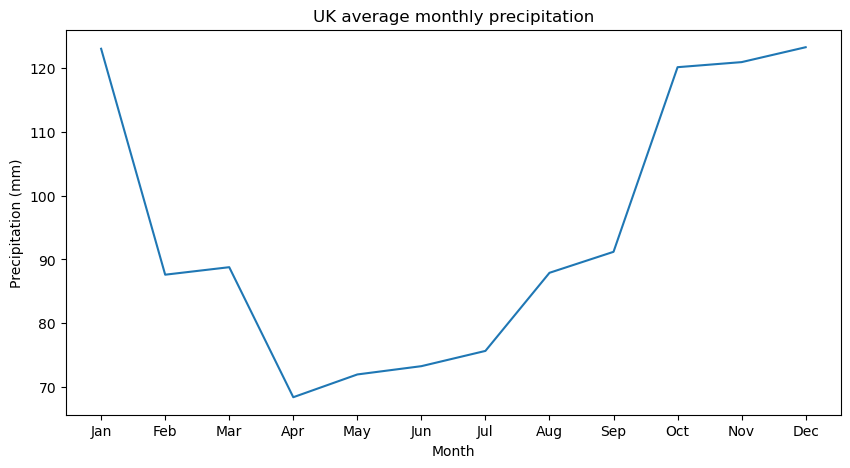

In [14]:
# plotting monthly precipitation

import matplotlib.pyplot as plt

months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(10,5))

plt.plot(monthly_mean.index, monthly_mean.values)

plt.xticks(range(1,13), months)

plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.title("UK average monthly precipitation")

plt.grid(False)
plt.show()
